In [4]:
import pandas as pd

In [5]:
df_sig = pd.read_csv('../data/pTau versus bacteria FDR 0.05.csv')
org_map_df = pd.read_csv('../results/species_to_kegg_org_candidates.csv')
presence_df = pd.read_csv("../results/species_by_kegg_pathway_presence.csv")
path_df = pd.read_csv("../results/kegg_pathway_id_to_name.csv")

In [26]:
df_sig

,btot,setot,pvtot,qqpvtot,z,bateria
0,0.006976,0.000477,1.960000e-17,6.740000e-14,aliivibriosalmonicid,Aliivibrio salmonicida
1,-0.742242,0.053256,9.880000e-17,1.700000e-13,burkholderialesbacte,Burkholderiales bacterium
2,0.533495,0.042495,2.820000e-15,3.230000e-12,citromicrobiumspjl47,Citromicrobium sp. JL47
3,-0.003420,0.000284,9.980000e-15,8.570000e-12,mucilaginibactergotj,Mucilaginibacter gotj
4,0.014854,0.001249,1.500000e-14,9.660000e-12,methylobacteriumspdm,Methylobacterium sp. DM
...,...,...,...,...,...,...
543,-0.131071,0.038386,1.503912e-03,9.497651e-03,methylomicrobiumbury,Methylomicrobium buryense
544,-0.002104,0.000616,1.506467e-03,9.497651e-03,olsenellaspgam18,Olsenella sp. GAM18
545,0.289593,0.084862,1.512683e-03,9.519377e-03,hylemonellagracilis,Hylemonella gracilis
546,-0.000655,0.000192,1.562346e-03,9.813933e-03,flavobacteriumjohnso,Flavobacterium johnsoniae


presence_df shape (species × pathways): (322, 39410)
Top species present in presence_df: 24
['Aliivibrio salmonicida', 'Burkholderiales bacterium', 'Citromicrobium sp. JL47', 'Mucilaginibacter gotj', 'Methylobacterium sp. DM', 'Agrobacterium tumefaciens', 'Roseburia hominis', 'Thermus scotoductus', 'Hafnia alvei', 'Erwinia gerundensis', 'Streptomyces pactum', 'Halomonas hydrothermalis', 'Treponema pedis', 'Arcobacter cryaerophilus', 'Kocuria rhizophila', 'Granulicella mallensis', 'Clostridium bornimens', 'Panacibacter ginsenosidivorans', 'Kocuria indica', 'Bordetella sp. J329', 'Moraxella bovoculi', 'Hyphomicrobium sp. MC1', 'Spiroplasma gladiator', 'Hydrogenobacter thermophilus']
Collapsed map matrix (top species): (24, 191)
Categorizable maps: 41
Final graph nodes: 27 edges: 48


/var/folders/pr/qsqt558j4r78hx4z6m7cdd9r0000gn/T/ipykernel_80279/1809238348.py:49: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  sub_map = sub_renamed.groupby(axis=1, level=0).max()


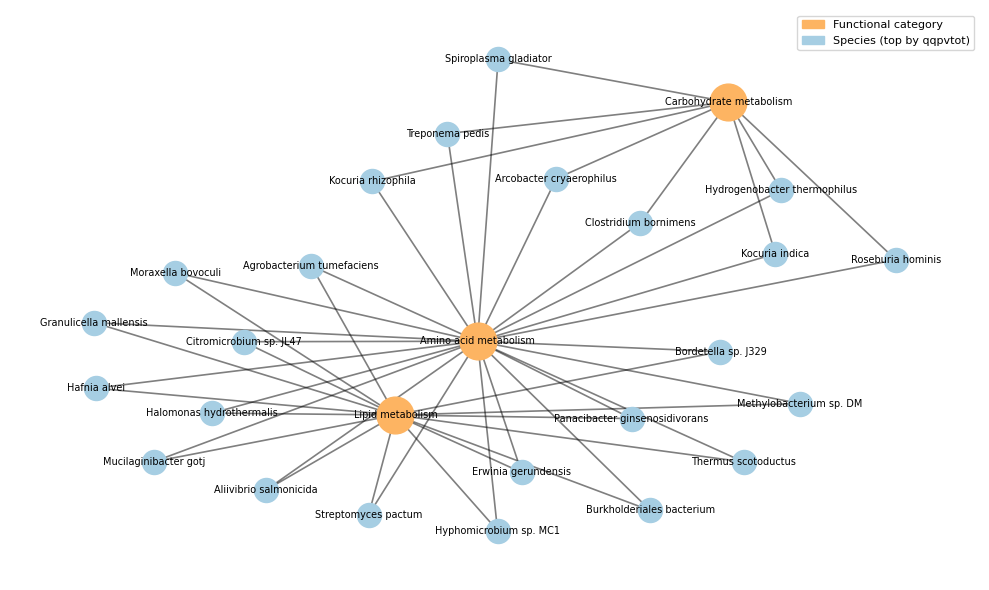

In [130]:
import re
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 0. make sure presence_df is species × pathway
# ---------------------------------------------------------
if presence_df.columns[0] not in set(path_df["pathway_id"]):
    presence_df = presence_df.set_index(presence_df.columns[0])

print("presence_df shape (species × pathways):", presence_df.shape)

# ---------------------------------------------------------
# 1. pick top N species by qqpvtot (df_sig is already sorted)
# ---------------------------------------------------------
N_SPECIES = 30        # or 10 if you want fewer
fdr_col = "qqpvtot"
species_col = "bateria"

top_species = df_sig.head(N_SPECIES)[species_col].tolist()
top_species_present = [s for s in top_species if s in presence_df.index]
print("Top species present in presence_df:", len(top_species_present))
print(top_species_present)

sub_pres = presence_df.loc[top_species_present]

# ---------------------------------------------------------
# 2. collapse organism-specific pathway IDs → KEGG map IDs
# ---------------------------------------------------------
path_df = path_df.copy()

def get_map_id(pid):
    m = re.search(r"(\d{5})", pid)
    return f"map{m.group(1)}" if m else pid

path_df["map_id"] = path_df["pathway_id"].apply(get_map_id)
path_df["generic_name"] = path_df["pathway_name"].str.split(" - ").str[0]

id_to_map   = dict(zip(path_df["pathway_id"], path_df["map_id"]))
map_to_name = path_df.drop_duplicates("map_id").set_index("map_id")["generic_name"].to_dict()

# keep only columns with known pathway IDs
valid_ids = set(path_df["pathway_id"])
sub_pres = sub_pres.loc[:, [c for c in sub_pres.columns if c in valid_ids]]

# rename to map IDs and collapse duplicates by OR
sub_renamed = sub_pres.rename(columns=id_to_map)
sub_map = sub_renamed.groupby(axis=1, level=0).max()
print("Collapsed map matrix (top species):", sub_map.shape)

# ---------------------------------------------------------
# 3. assign each KEGG map to ONE coarse functional category
# ---------------------------------------------------------
AA_WORDS = [
    "alanine", "aspartate", "glutamate", "glycine", "serine", "threonine",
    "valine", "leucine", "isoleucine", "lysine", "arginine", "proline",
    "histidine", "cysteine", "methionine", "phenylalanine", "tyrosine",
    "tryptophan"
]

def coarse_category(name: str):
    """Return one of the 6 categories or None."""
    n = name.lower()
    # 1. Biotin (specific)
    if "biotin metabolism" in n:
        return "Biotin metabolism"
    # 2. Energy metabolism
    if ("oxidative phosphorylation" in n or "carbon fixation" in n or
        "tca cycle" in n or "citrate cycle" in n):
        return "Energy metabolism"
    # 3. SCFA (short-chain fatty acids)
    if any(w in n for w in ["butanoate metabolism", "butyrate", "propanoate metabolism",
                            "propionate", "short-chain fatty"]):
        return "SCFA metabolism"
    # 4. Lipid metabolism
    if ("lipid metabolism" in n or "fatty acid" in n or
        "glycerolipid" in n or "glycerophospholipid" in n or
        "sphingolipid" in n or "ether lipid" in n or "steroid" in n):
        return "Lipid metabolism"
    # 5. Amino acid metabolism
    if "amino acid" in n or any(w in n for w in AA_WORDS):
        return "Amino acid metabolism"
    # 6. Carbohydrate metabolism
    if any(w in n for w in ["glycolysis", "gluconeogenesis", "starch and sucrose",
                            "fructose and mannose", "galactose metabolism",
                            "pentose phosphate", "amino sugar and nucleotide sugar"]):
        return "Carbohydrate metabolism"
    return None

map_to_cat = {}
for mid, name in map_to_name.items():
    cat = coarse_category(name)
    if cat is not None:
        map_to_cat[mid] = cat

# restrict to maps we can categorize
sub_map = sub_map.loc[:, [c for c in sub_map.columns if c in map_to_cat]]
print("Categorizable maps:", sub_map.shape[1])

if sub_map.shape[1] == 0:
    raise ValueError("No KEGG maps could be assigned to the 6 coarse categories.")

# ---------------------------------------------------------
# 4. compute per-species counts of each category
# ---------------------------------------------------------
categories = [
    "Amino acid metabolism",
    "Carbohydrate metabolism",
    "Lipid metabolism",
    "SCFA metabolism",
    "Energy metabolism",
    "Biotin metabolism",
]

# count how many maps of each category each species carries
species_cat_counts = {sp: {cat: 0 for cat in categories} for sp in sub_map.index}

for sp, row in sub_map.iterrows():
    for mid, val in row.items():
        if val == 1 and mid in map_to_cat:
            cat = map_to_cat[mid]
            if cat in species_cat_counts[sp]:
                species_cat_counts[sp][cat] += 1

# ---------------------------------------------------------
# 5. build bipartite graph: species ↔ functional categories
#    edges only to top-K categories per species
# ---------------------------------------------------------
TOP_K_CAT_PER_SPECIES = 2   # at most 2 strongest categories per species

B = nx.Graph()

# add category nodes (orange in the example)
for cat in categories:
    B.add_node(cat, bipartite="category")

# add species nodes and edges
for sp, counts in species_cat_counts.items():
    # keep only non-zero categories
    nonzero = [(cat, cnt) for cat, cnt in counts.items() if cnt > 0]
    if not nonzero:
        continue
    # top-K categories by count
    nonzero.sort(key=lambda x: x[1], reverse=True)
    for cat, cnt in nonzero[:TOP_K_CAT_PER_SPECIES]:
        B.add_node(sp, bipartite="species")
        B.add_edge(sp, cat, weight=cnt)

# remove isolated nodes
B.remove_nodes_from(list(nx.isolates(B)))

print("Final graph nodes:", B.number_of_nodes(), "edges:", B.number_of_edges())

# ---------------------------------------------------------
# 6. plot: blue species, orange functional categories
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(B, k=0.6, iterations=300)

species_nodes = [n for n, d in B.nodes(data=True) if d["bipartite"] == "species"]
category_nodes = [n for n, d in B.nodes(data=True) if d["bipartite"] == "category"]

# species nodes (light blue)
nx.draw_networkx_nodes(
    B, pos,
    nodelist=species_nodes,
    node_color="#a6cee3",
    node_size=300,
    node_shape="o",
)

# category nodes (orange)
nx.draw_networkx_nodes(
    B, pos,
    nodelist=category_nodes,
    node_color="#fdb462",
    node_size=700,
    node_shape="o",
)

# draw regular unweighted edges
nx.draw_networkx_edges(B, pos, width=1.2, alpha=0.5)


nx.draw_networkx_labels(B, pos, font_size=7)

plt.axis("off")

from matplotlib.legend_handler import HandlerPatch
from matplotlib.patches import Circle

handles = [
    Circle((0, 0), radius=0.1, color="#fdb462", label="Functional category"),
    Circle((0, 0), radius=0.1, color="#a6cee3", label="Species (top by qqpvtot)"),
]
plt.legend(handles=handles, labels=["Functional category", "Species (top by qqpvtot)"],
           loc="upper right", fontsize=8, frameon=True)

plt.tight_layout()
plt.savefig("../results/coarse_functional_network.pdf", dpi=600)  # leave commented if you don't want a file yet
plt.show()


In [127]:
# ==========================================
# Build summary table: category → KEGG → species
# ==========================================
rows = []

for mid in sub_map.columns:
    cat = map_to_cat[mid]                       # functional category
    pname = map_to_name.get(mid, mid)          # KEGG pathway name
    # which of the top species have this KEGG map?
    species_with = [sp for sp in sub_map.index if sub_map.loc[sp, mid] == 1]
    if not species_with:
        continue
    rows.append({
        "Category": cat,
        "KEGG_map_id": mid,
        "Pathway_name": pname,
        "Species_n": len(species_with),
        "Species_list": "; ".join(species_with),
    })

kegg_category_table = (
    pd.DataFrame(rows)
      .sort_values(["Category", "Pathway_name"])
      .reset_index(drop=True)
)

kegg_category_table


,Category,KEGG_map_id,Pathway_name,Species_n,Species_list
0,Amino acid metabolism,map00250,"Alanine, aspartate and glutamate metabolism",24,Aliivibrio salmonicida; Burkholderiales bacter...
1,Amino acid metabolism,map00330,Arginine and proline metabolism,24,Aliivibrio salmonicida; Burkholderiales bacter...
2,Amino acid metabolism,map00220,Arginine biosynthesis,24,Aliivibrio salmonicida; Burkholderiales bacter...
3,Amino acid metabolism,map01230,Biosynthesis of amino acids,24,Aliivibrio salmonicida; Burkholderiales bacter...
4,Amino acid metabolism,map00460,Cyanoamino acid metabolism,23,Aliivibrio salmonicida; Burkholderiales bacter...
5,Amino acid metabolism,map00270,Cysteine and methionine metabolism,24,Aliivibrio salmonicida; Burkholderiales bacter...
6,Amino acid metabolism,map00470,D-Amino acid metabolism,23,Aliivibrio salmonicida; Burkholderiales bacter...
7,Amino acid metabolism,map00260,"Glycine, serine and threonine metabolism",24,Aliivibrio salmonicida; Burkholderiales bacter...
8,Amino acid metabolism,map00340,Histidine metabolism,23,Aliivibrio salmonicida; Burkholderiales bacter...
9,Amino acid metabolism,map00300,Lysine biosynthesis,23,Aliivibrio salmonicida; Burkholderiales bacter...


In [128]:
# ==========================================
# Build species → category → KEGG table
# ==========================================

rows2 = []

for sp in sub_map.index:
    # all KEGG maps this species has (1’s in sub_map)
    species_maps = [mid for mid, val in sub_map.loc[sp].items() if val == 1]
    
    for mid in species_maps:
        if mid not in map_to_cat:
            continue  # skip uncategorized
        cat = map_to_cat[mid]
        pname = map_to_name.get(mid, mid)
        
        rows2.append({
            "Species": sp,
            "Category": cat,
            "KEGG_map_id": mid,
            "Pathway_name": pname
        })

species_kegg_table = (
    pd.DataFrame(rows2)
      .sort_values(["Species", "Category", "Pathway_name"])
      .reset_index(drop=True)
)

species_kegg_table


,Species,Category,KEGG_map_id,Pathway_name
0,Agrobacterium tumefaciens,Amino acid metabolism,map00250,"Alanine, aspartate and glutamate metabolism"
1,Agrobacterium tumefaciens,Amino acid metabolism,map00330,Arginine and proline metabolism
2,Agrobacterium tumefaciens,Amino acid metabolism,map00220,Arginine biosynthesis
3,Agrobacterium tumefaciens,Amino acid metabolism,map01230,Biosynthesis of amino acids
4,Agrobacterium tumefaciens,Amino acid metabolism,map00460,Cyanoamino acid metabolism
...,...,...,...,...
887,Treponema pedis,Lipid metabolism,map00561,Glycerolipid metabolism
888,Treponema pedis,Lipid metabolism,map00564,Glycerophospholipid metabolism
889,Treponema pedis,Lipid metabolism,map00600,Sphingolipid metabolism
890,Treponema pedis,SCFA metabolism,map00650,Butanoate metabolism


In [131]:
species_kegg_table.to_csv('../results/corse_species_kegg_table.csv', index=False)
kegg_category_table.to_csv('../results/corse_kegg_species_table.csv', index=False)